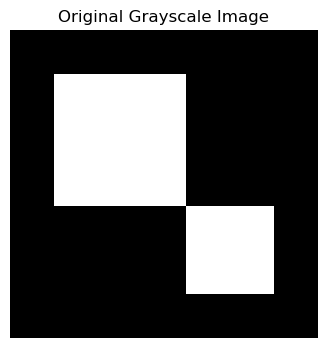

In [2]:
# Code Example: convolution_fundamentals.ipynb
# Chapter 22: Understanding Convolution
# Building and visualizing convolution operations from scratch

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Create a simple grayscale image
# --------------------------------------------------

image = torch.tensor([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0, 0],
    [0, 1, 1, 1, 0, 0, 0],
    [0, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0]
], dtype=torch.float32)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()



In [6]:

# --------------------------------------------------
# 2. Define convolution kernels
# --------------------------------------------------

vertical_edge_kernel = torch.tensor([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=torch.float32)

horizontal_edge_kernel = torch.tensor([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=torch.float32)

sharpen_kernel = torch.tensor([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=torch.float32)



In [15]:

# --------------------------------------------------
# 3. Build convolution from scratch
# --------------------------------------------------

def apply_convolution(image, kernel):

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = torch.zeros(
        output_height,
        output_width
    )

    for row in range(output_height):

        for col in range(output_width):

            image_region = image[
                row:row + kernel_height,
                col:col + kernel_width
            ]

            output[row, col] = torch.sum(
                image_region * kernel
            )

    return output



In [16]:

# --------------------------------------------------
# 4. Apply different kernels
# --------------------------------------------------

vertical_edges = apply_convolution(
    image,
    vertical_edge_kernel
)

horizontal_edges = apply_convolution(
    image,
    horizontal_edge_kernel
)

sharpened_image = apply_convolution(
    image,
    sharpen_kernel
)



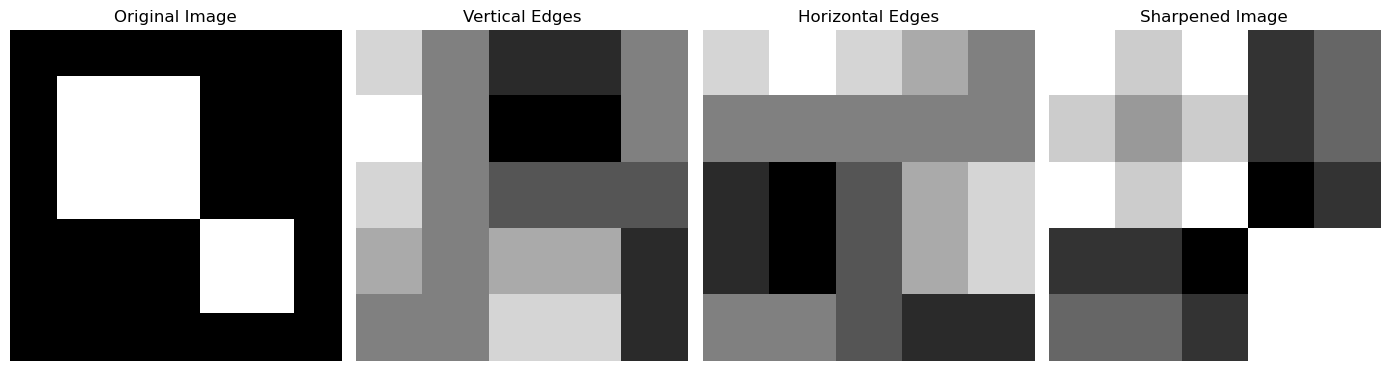

In [17]:

# --------------------------------------------------
# 5. Visualize convolution outputs
# --------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

images = [
    image,
    vertical_edges,
    horizontal_edges,
    sharpened_image
]

titles = [
    "Original Image",
    "Vertical Edges",
    "Horizontal Edges",
    "Sharpened Image"
]

for ax, img, title in zip(axes, images, titles):

    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [18]:


# --------------------------------------------------
# 6. Demonstrate padding
# --------------------------------------------------

image_4d = image.unsqueeze(0).unsqueeze(0)

kernel_4d = vertical_edge_kernel.unsqueeze(0).unsqueeze(0)

output_without_padding = F.conv2d(
    image_4d,
    kernel_4d,
    padding=0
)

output_with_padding = F.conv2d(
    image_4d,
    kernel_4d,
    padding=1
)

print("Original Image Shape:", image_4d.shape)
print("Without Padding Shape:", output_without_padding.shape)
print("With Padding Shape:", output_with_padding.shape)


Original Image Shape: torch.Size([1, 1, 7, 7])
Without Padding Shape: torch.Size([1, 1, 5, 5])
With Padding Shape: torch.Size([1, 1, 7, 7])


In [19]:


# --------------------------------------------------
# 7. Demonstrate stride
# --------------------------------------------------

output_stride_1 = F.conv2d(
    image_4d,
    kernel_4d,
    stride=1
)

output_stride_2 = F.conv2d(
    image_4d,
    kernel_4d,
    stride=2
)

print("Stride 1 Output Shape:", output_stride_1.shape)
print("Stride 2 Output Shape:", output_stride_2.shape)



Stride 1 Output Shape: torch.Size([1, 1, 5, 5])
Stride 2 Output Shape: torch.Size([1, 1, 3, 3])


In [20]:

# --------------------------------------------------
# 8. Demonstrate pooling
# --------------------------------------------------

pooled_max = F.max_pool2d(
    image_4d,
    kernel_size=2,
    stride=2
)

pooled_avg = F.avg_pool2d(
    image_4d,
    kernel_size=2,
    stride=2
)

print("Max Pooling Output Shape:", pooled_max.shape)
print("Average Pooling Output Shape:", pooled_avg.shape)



Max Pooling Output Shape: torch.Size([1, 1, 3, 3])
Average Pooling Output Shape: torch.Size([1, 1, 3, 3])


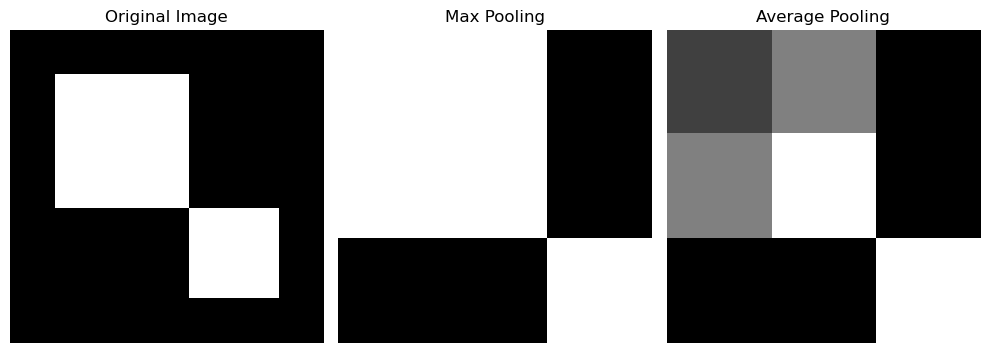

In [21]:

# --------------------------------------------------
# 9. Visualize pooling results
# --------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(pooled_max.squeeze(), cmap="gray")
axes[1].set_title("Max Pooling")
axes[1].axis("off")

axes[2].imshow(pooled_avg.squeeze(), cmap="gray")
axes[2].set_title("Average Pooling")
axes[2].axis("off")

plt.tight_layout()
plt.show()



In [22]:

# --------------------------------------------------
# 10. Create a simple Conv2D layer
# --------------------------------------------------

conv_layer = torch.nn.Conv2d(
    in_channels=1,
    out_channels=3,
    kernel_size=3,
    padding=1
)

feature_maps = conv_layer(image_4d)

print("Feature Map Shape:", feature_maps.shape)



Feature Map Shape: torch.Size([1, 3, 7, 7])


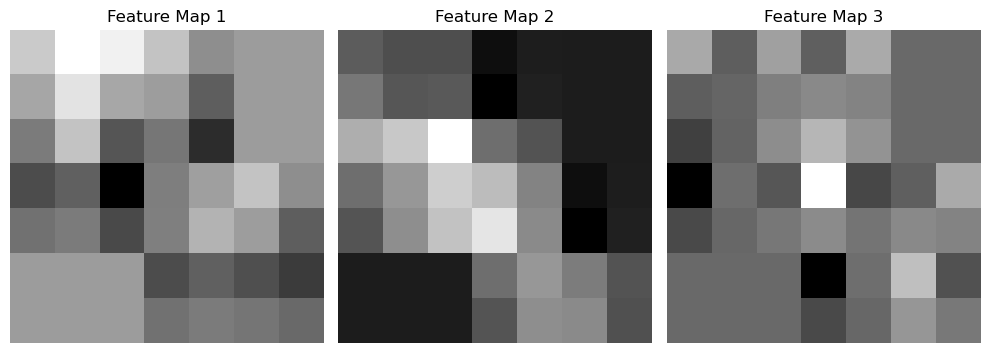

In [23]:

# --------------------------------------------------
# 11. Visualize feature maps
# --------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for i in range(3):

    axes[i].imshow(
        feature_maps[0, i].detach(),
        cmap="gray"
    )

    axes[i].set_title(f"Feature Map {i + 1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()